## Tearing-mode dispersion: growth rate vs wavenumber

Companion to `tearing-mode-2D.ipynb`, which measured the tearing growth rate against
*resistivity* at a fixed wavenumber $k=1/2$ (finding $\gamma = 0.0249$ at
$\eta=10^{-3}$, in an inviscid run like this one). Here we hold $\eta = 10^{-3}$ fixed and measure the **dispersion curve**
$\gamma(k)$ across the whole unstable band, resolving its peak. The peak matters: a real
current sheet is perturbed at all wavelengths at once, and the island chain it actually
tears into is selected by the fastest-growing mode. The same competition -- $\Delta'(k)$
large but layer coupling weak at small $k$, $\Delta' \to 0$ as $k \to 1$ -- reappears in
plasmoid-unstable sheets, where "which $k$ wins" sets the number of plasmoids.

**One simulation gives the whole curve.** We use the same equilibrium
$\psi_{eq}=\cos(x)$ in $L_x = 2\pi$, but a *long* box in $y$: $L_y = 16\pi$, so the mode
spacing is $\Delta k = 1/8$ and the unstable band $0<k<1$ contains seven modes
($m=1..7$). We seed all of $m=1..10$ at once with tiny random-phase perturbations:
in the linear phase the different $k_y$ modes evolve independently (the only
coupling is through the quadratic nonlinearity, negligible while amplitudes are small),
so each mode's amplitude grows at its own $\gamma(k)$. Modes $m=8$ ($k=1$, marginal) and
$m=9,10$ ($k>1$, stable) are deliberate negative controls.

**fp64 is essential here, and is the point of the design.** The seed amplitude is
$\epsilon=10^{-7}$ relative to the equilibrium, which at fp64 (rounding floor
$\sim10^{-16}$) buys every mode 4-6 clean decades of exponential growth before
nonlinear contamination. At fp32 the rounding noise of the $O(1)$ equilibrium is itself
$\sim10^{-7}$ relative -- the slow modes would sit *in* the noise floor, and even the
fast ones would get barely a decade of fit window. Hence the first code cell sets
`RMHD_PRECISION=64` **before** any `jax_rmhd`/`jax` import (it is read at import time).

Runtime: the generation run is roughly 10-15 minutes on a laptop CPU at fp64 (about
20,000 timesteps at $128\times1024$); as in the other notebooks it is skipped
automatically if a completed run is already on disk.

In [1]:
#fp64 MUST be selected before jax_rmhd (or jax) is imported -- RMHD_PRECISION is
#read once at import time. See the markdown above for why fp32 cannot do this problem.
import os
os.environ["RMHD_PRECISION"] = "64"

import jax_rmhd as jr
import jax.numpy as jnp
import jax.numpy.fft as ft
import numpy as np
import matplotlib.pyplot as plt

import jax_rmhd.snapshot_io as sn

jax is using 64bit precision.


### Setup and run

$128\times1024$ on $L_x=2\pi$, $L_y=16\pi$; true Laplacian resistivity (`hyper=1`) with
$\eta=10^{-3}$ and **zero viscosity** (`diss=(0.0, eta)`: $\nu=0$, $Pm=0$) -- same
equilibrium, $\eta$ and inviscid setup as the featured run of `tearing-mode-2D.ipynb`.

**Why inviscid.** The exact (Coppi) dispersion relation this notebook tests below is
derived for an *inviscid* resistive layer. An earlier version of this notebook ran at
$Pm=1$ ($\nu=\eta=10^{-3}$) and measured $\gamma$ roughly $20\%$ below the
decay-corrected exact curve at the peak -- viscous drag on the layer, which the relation
simply does not contain. With $\nu=0$ the comparison is apples-to-apples -- and
`tearing-mode-2D` is now inviscid too, so its $k=1/2$ growth rate doubles as an
independent cross-check of this run at the end.
The initial condition is

$$\psi = \cos x + \epsilon\sum_{m=1}^{10}\cos\!\big(m\,\Delta k\,y + \varphi_m\big),
\qquad \Delta k = \tfrac18,\quad \epsilon=10^{-7},$$

with fixed pseudo-random phases $\varphi_m$ (seeded, so the run is reproducible) to
avoid accidentally aligning all the modes at $y=0$. $\phi=0$: we start at rest.

Two caveats to carry through the analysis (both inherited from `tearing-mode-2D`):

- nothing holds the equilibrium up against resistive diffusion, so $\psi_{eq}$ decays as
  $e^{-\eta t}$ and every instantaneous growth rate drifts slowly downward over the run
  -- we fit early and quote the window;
- the modes are only uncoupled *while amplitudes are small*; once any mode gets large,
  quadratic beats contaminate its neighbours (quantified below, and visible in the data).

In [2]:
nx, ny = 128, 1024
Lx = 2.0 * jnp.pi
Ly = 16.0 * jnp.pi        #mode spacing dk = 2*pi/Ly = 1/8
eta = 1e-3                #resistivity; viscosity is ZERO (inviscid, Pm = 0)
eps = 1e-7                #seed amplitude: tiny on purpose -- see the fp64 note above
dk = 0.125
nmodes = 10               #m = 1..7 unstable, m = 8 marginal (k=1), m = 9,10 stable
t_snap, t_end = 5.0, 500.0
snap_path = "data/tearing-growth-vs-k/"

rng = np.random.default_rng(20260730)     #fixed seed: reproducible phases
phases = rng.uniform(0.0, 2.0 * np.pi, size=nmodes)

def tearing_init(x, y):
    psi = jnp.cos(x)
    for m in range(1, nmodes + 1):
        psi = psi + eps * jnp.cos(m * dk * y + phases[m - 1])
    return jnp.stack([jnp.zeros_like(psi), psi], axis=0)

params = jr.Parameters(nx=nx, ny=ny, Lx=Lx, Ly=Ly,
                       eqpars={'diss': (0.0, eta), 'hyper': 1},
                       cfl_safety=0.5, dims=2)
#record the constructor args (and precision) into the run directory BEFORE running:
#the directory then documents itself, and re-saving identical params later is a no-op
params.save(snap_path)
kgrid = jr.setup_kgrids(params)

#skip-guard: reuse a run already on disk (same pattern as turbulence-spectra-analysis)
if len(sn.get_saved_steps(snap_path)) == 0:
    print("no existing run found -- generating one (~10-15 min at fp64)")
    mngr = jr.snapshot_manager_setup(params, snap_path=snap_path, nsnap=1000)
    state = jr.initialize(tearing_init, params)
    nblock = jr.estimate_good_nblock(state, kgrid, params, t_snap, t_end, nblock_min=10)
    #buffer donation: simulate_scan CONSUMES `state`; everything below works from
    #the saved snapshots instead
    jr.simulate_scan(state, kgrid, params, nblock, t_snap=t_snap, t_end=t_end,
                     mngr=mngr, save=True, print_every=50)
else:
    print(f"reusing existing run in {snap_path}")

reusing existing run in data/tearing-growth-vs-k/


### Per-mode amplitudes and growth-rate fits

The amplitude of mode $m$ is read straight out of each snapshot:
$A_m(t) = |\hat\psi(k_x{=}0,\,k_y{=}m\Delta k)|$, i.e. `fields[1][0, 0, m]`. The ffts
are unnormalized, so an $O(1)$ real field has coefficients of order $n_x n_y$; we quote
*relative* amplitudes $A_m/(n_x n_y/2)$, on which the seed is $10^{-7}$ and the
equilibrium is $1$.

**Fit windows.** For each mode we fit a straight line to $\ln A_m(t)$ over
$[t_{lo,m},\,t_{nl}]$:

- $t_{lo,m}$: where $A_m$ first reaches $10\times$ its seed -- past the initial
  transient in which the $\cos(k y)$ perturbation relaxes onto the true tearing
  eigenfunction. The slow and stable modes never get there, so they fall back to
  $t_{lo}=25$ (a few Alfven times).
- $t_{nl}$: a **global** cutoff where the *largest* mode reaches relative amplitude
  $10^{-3}$. The reason it must be global: the quadratic nonlinearity drives mode
  $m = m'+m''$ at the *sum* rate $\gamma_{m'}+\gamma_{m''}$. E.g. the $m{=}9$ beat of
  $m{=}4$ and $m{=}5$ grows at $\approx 0.043$, an order of magnitude faster than
  anything linear near the band edge -- starting from a product of tiny amplitudes, it
  surfaces late but then overtakes the slow modes long before the fast modes saturate.
  And with every unstable rate now $\sim40\%$ faster than in the old $Pm=1$ version of
  this run, the beats surface *earlier*: in the amplitude plot below the decaying
  controls bottom out and turn around at $t\approx175$ ($m{=}10$) and $t\approx290$
  ($m{=}9$), i.e. the beats intrude into the *stable* modes' fit windows themselves.
  Their fitted "decay rates" carry large residuals and should be read qualitatively
  (decays until the beats arrive), not as clean linear rates; the unstable fits all
  stop at $t_{nl}$, well before any of this matters for them.

**Error bars.** The statistical slope error is tiny (thousands of e-foldings of data);
the *real* uncertainty is the slow downward drift of $\gamma$ as the equilibrium decays
($e^{-\eta t}$). We quote half the difference between fits over the two halves of each
window as a systematic error bar, and report the rms residual of $\ln A$ as fit quality.

In [3]:
steps = sn.get_saved_steps(snap_path)
ts, A = [], []
for i in steps:
    snap = sn.load_snapshot(i, snap_path, params)
    ts.append(float(snap.t))
    A.append(np.abs(np.asarray(snap.fields[1][0, 0, 1:nmodes + 1])))
ts = np.array(ts)
A = np.array(A)                       #(nt, nmodes)
Arel = A / (nx * ny / 2.0)            #relative to the O(1) equilibrium
ks = dk * np.arange(1, nmodes + 1)

rel_cut = 1e-3
t_nl = ts[int(np.argmax(Arel.max(axis=1) >= rel_cut))] if Arel.max() >= rel_cut else ts[-1]

def fit_mode(m, t_lo, t_hi):
    w = (ts >= t_lo) & (ts <= t_hi)
    coeffs, cov = np.polyfit(ts[w], np.log(A[w, m - 1]), 1, cov=True)
    resid = np.log(A[w, m - 1]) - np.polyval(coeffs, ts[w])
    return coeffs[0], float(np.sqrt(cov[0, 0])), float(np.sqrt(np.mean(resid**2))), int(w.sum())

gammas = np.empty(nmodes); g_stat = np.empty(nmodes); g_sys = np.empty(nmodes)
rmss = np.empty(nmodes); npts = np.empty(nmodes, dtype=int); t_los = np.empty(nmodes)
for m in range(1, nmodes + 1):
    crossed = np.nonzero(Arel[:, m - 1] >= 10.0 * Arel[0, m - 1])[0]
    t_lo = ts[crossed[0]] if len(crossed) and ts[crossed[0]] < t_nl - 100.0 else 25.0
    t_lo = max(t_lo, 25.0)
    g, ge, rms, n = fit_mode(m, t_lo, t_nl)
    tmid = 0.5 * (t_lo + t_nl)
    g_a = fit_mode(m, t_lo, tmid)[0]      #first half of the window vs
    g_b = fit_mode(m, tmid, t_nl)[0]      #second half: the drift is the error bar
    gammas[m-1], g_stat[m-1], g_sys[m-1] = g, ge, 0.5 * abs(g_a - g_b)
    rmss[m-1], npts[m-1], t_los[m-1] = rms, n, t_lo

print(f"linear-phase cutoff: t_nl = {t_nl:.0f} "
      f"(largest mode reaches relative amplitude {rel_cut:g})\n")
print(" m     k     fit window       n    gamma     +-sys     rms(lnA)")
for m in range(1, nmodes + 1):
    print(f"{m:2d}  {ks[m-1]:5.3f}  [{t_los[m-1]:5.1f}, {t_nl:5.1f}]  {npts[m-1]:3d}  "
          f"{gammas[m-1]:+.5f}  {g_sys[m-1]:.5f}   {rmss[m-1]:.3f}")

linear-phase cutoff: t_nl = 287 (largest mode reaches relative amplitude 0.001)

 m     k     fit window       n    gamma     +-sys     rms(lnA)
 1  0.125  [ 72.3, 286.5]   37  +0.02065  0.00062   0.020
 2  0.250  [ 45.9, 286.5]   42  +0.02901  0.00100   0.037
 3  0.375  [ 51.1, 286.5]   41  +0.02932  0.00095   0.034
 4  0.500  [ 67.0, 286.5]   38  +0.02465  0.00065   0.022
 5  0.625  [ 99.4, 286.5]   32  +0.01832  0.00038   0.011
 6  0.750  [167.8, 286.5]   20  +0.01195  0.00015   0.003
 7  0.875  [ 25.0, 286.5]   46  +0.00581  0.00018   0.009
 8  1.000  [ 25.0, 286.5]   46  -0.00099  0.00002   0.001
 9  1.125  [ 25.0, 286.5]   46  -0.01325  0.00599   0.266
10  1.250  [ 25.0, 286.5]   46  -0.01148  0.01727   0.873


On the semilog plot each unstable mode is a clean straight line over 4-6 decades --
this is what seeding at $10^{-7}$ in fp64 buys. Note the negative controls doing their
job ($m=8$ decays at almost exactly $\eta k^2$, $m=9,10$ faster), and then the
advertised nonlinear beats: $m=10$ bottoms out near $t\approx175$ and $m=9$ near
$t\approx290$, after which they *grow* at sum rates, and past the dashed cutoff the
whole mode-independence assumption dies -- everything right of that line is excluded
from the fits.

Text(0.5, 1.0, 'Per-mode island amplitudes (relative to the equilibrium)')

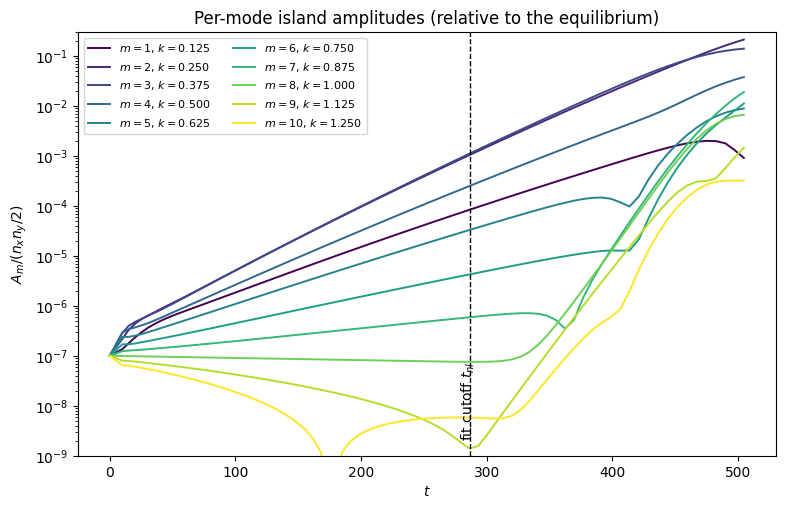

In [4]:
plt.figure(figsize=(9, 5.5))
cmap = plt.cm.viridis
for m in range(1, nmodes + 1):
    plt.semilogy(ts, Arel[:, m - 1], color=cmap((m - 1) / (nmodes - 1)), lw=1.4,
                 label=rf"$m={m}$, $k={ks[m-1]:.3f}$")
plt.axvline(t_nl, color="k", ls="--", lw=1)
plt.text(t_nl - 8, 2e-9, r"fit cutoff $t_{nl}$", rotation=90, va="bottom")
plt.xlabel(r"$t$")
plt.ylabel(r"$A_m/(n_x n_y/2)$")
plt.ylim(1e-9, 0.3)
plt.legend(fontsize=8, ncol=2, loc="upper left")
plt.title("Per-mode island amplitudes (relative to the equilibrium)")

### What the field looks like

Current density $j=-\nabla_\perp^2\psi$ with field-line contours of $\psi$ overlaid, at
the fit cutoff and at the end of the run. At $t_{nl}$ the sheet still looks like the
equilibrium (the perturbations are at $10^{-3}$ relative). By $t=500$ the
fastest-growing modes have formed visible island chains on both resonant surfaces
($x=0$ and $x=\pi$) -- and because several $k$'s are growing at comparable rates, the
chains are visibly *irregular*: neighbouring islands compete, which is how mode
selection looks in real space.

**Inviscid late-time health check.** With $\nu=0$ nothing damps vorticity at the grid
scale, so this deserves a look: past $t\approx450$ the vorticity spectrum flattens
near the dealiasing cutoff -- the X-point vorticity layers steepen with no viscous
width to stop at, and by $t=500$ they are only marginally resolved. The fields remain
finite and visually coherent (sharp current sheets and X-point vorticity quadrupoles,
no grid-scale noise), and every quantitative fit ends at $t_{nl}\approx287$, far
earlier -- but this is why the run stops at $t=500$: an inviscid box should not be
pushed much beyond island saturation.

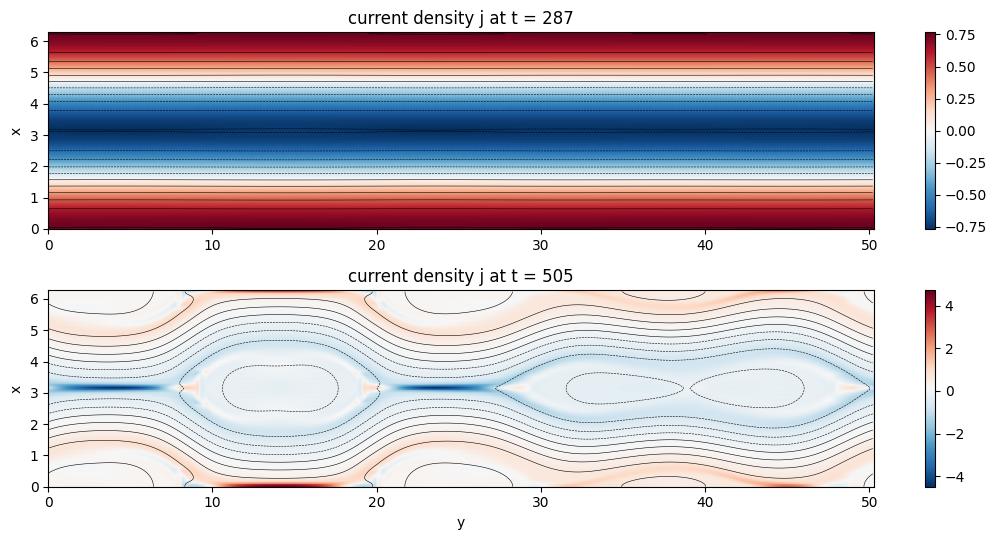

In [5]:
x = np.linspace(0, float(Lx), nx, endpoint=False)
y = np.linspace(0, float(Ly), ny, endpoint=False)
picks = [int(np.argmin(np.abs(ts - t_nl))), len(steps) - 1]
fig, axes = plt.subplots(2, 1, figsize=(11, 5.5))
for ax, i in zip(axes, picks):
    snap = sn.load_snapshot(steps[i], snap_path, params)
    jz = np.asarray(ft.irfft2(kgrid.ksq * snap.fields[1, 0]))   #j = -grad_perp^2 psi
    psi = np.asarray(ft.irfft2(snap.fields[1, 0]))
    im = ax.imshow(jz, origin="lower", extent=(0, float(Ly), 0, float(Lx)),
                   cmap="RdBu_r", aspect="auto")
    ax.contour(y, x, psi, levels=12, colors="k", linewidths=0.4)
    ax.set_title(f"current density j at t = {float(snap.t):.0f}")
    ax.set_ylabel("x")
    fig.colorbar(im, ax=ax)
axes[-1].set_xlabel("y")
plt.tight_layout()

### Structure vs time: watching mode selection happen

The two stills above hide the best part: the *perturbation* current
$\delta j$ (total $j$ with the $k_y=0$ columns -- the equilibrium and its resistive
decay -- removed) organizing itself from random-phase multi-mode interference into the
winning island chain. Its amplitude spans many decades over the run, so a fixed color
scale would show nothing early: each frame is normalized by its own $\max|\delta j|$,
with $t$ and $\max|\delta j|$ annotated so the exponential growth stays readable while
the colors show pure structure. Once the islands are macroscopic, contours of the
*total* $\psi$ are overlaid so the separatrices appear. The GIF is written into the
(gitignored) run directory and rebuilt only if missing; representative stills are shown
inline.

reusing existing data/tearing-growth-vs-k/delta_j_evolution.gif
81 frames, 3.5 MB


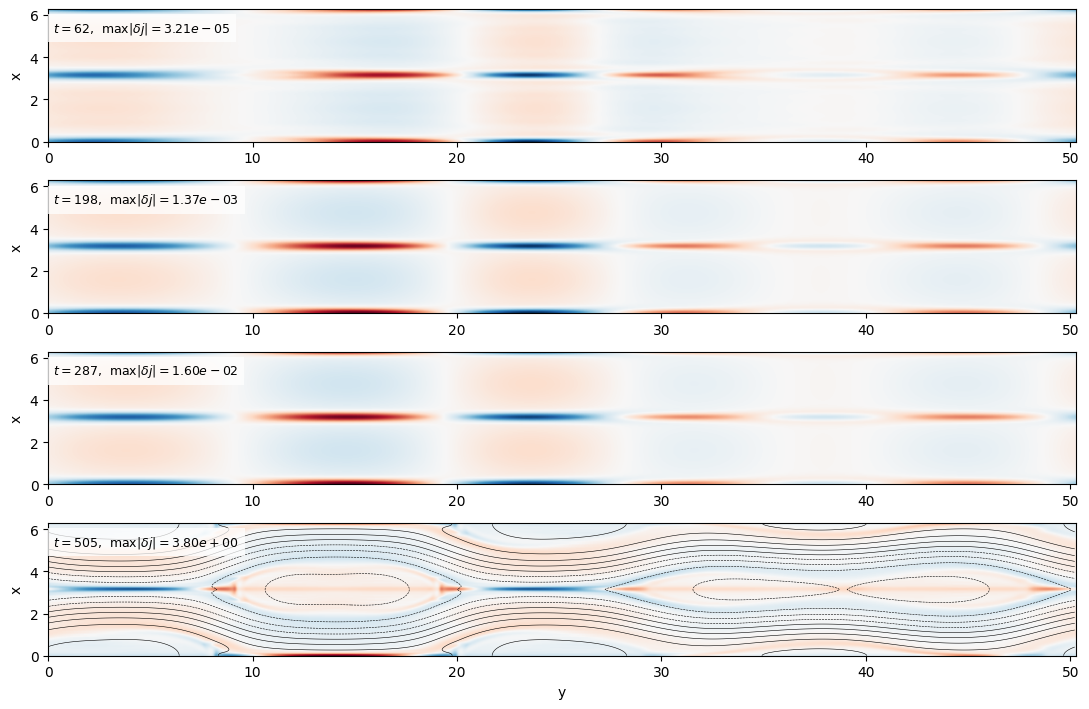

In [6]:
import matplotlib.animation as manim

gif_path = os.path.join(snap_path, "delta_j_evolution.gif")
stride = int(np.ceil(len(steps) / 100.0))          #keep the GIF to <= 100 frames
frame_steps = list(steps[::stride])
if frame_steps[-1] != steps[-1]:
    frame_steps.append(steps[-1])

ksq_np = np.asarray(kgrid.ksq)

def load_delta_j(istep):
    #perturbation current density: zero the ky=0 column (rfft2 layout: ky=0 is
    #index 0 of the last axis) -- that column IS the decaying equilibrium
    snap = sn.load_snapshot(istep, snap_path, params)
    psik = np.array(snap.fields[1, 0])
    psik_pert = psik.copy()
    psik_pert[:, 0] = 0.0
    dj = np.asarray(ft.irfft2(ksq_np * psik_pert))
    psi = np.asarray(ft.irfft2(psik))
    return float(snap.t), dj, psi

if os.path.exists(gif_path):
    print(f"reusing existing {gif_path}")
else:
    fig, ax = plt.subplots(figsize=(12.0, 2.4), dpi=80)
    _, dj0, _ = load_delta_j(frame_steps[0])
    im = ax.imshow(dj0 / np.abs(dj0).max(), origin="lower",
                   extent=(0, float(Ly), 0, float(Lx)), cmap="RdBu_r",
                   aspect="auto", vmin=-1.0, vmax=1.0)
    label = ax.text(0.005, 0.93, "", transform=ax.transAxes, va="top", fontsize=9,
                    bbox=dict(facecolor="w", alpha=0.75, edgecolor="none"))
    ax.set_xlabel("y"); ax.set_ylabel("x")
    contours = []
    def update(fi):
        t, dj, psi = load_delta_j(frame_steps[fi])
        mx = float(np.abs(dj).max())
        im.set_data(dj / mx)
        label.set_text(rf"$t = {t:.0f}$    max$|\delta j| = {mx:.2e}$")
        while contours:
            contours.pop().remove()
        if mx > 0.05:      #islands macroscopic: overlay total-psi field lines
            contours.append(ax.contour(y, x, psi, levels=8, colors="k",
                                       linewidths=0.4))
        return [im, label]
    anim = manim.FuncAnimation(fig, update, frames=len(frame_steps))
    anim.save(gif_path, writer=manim.PillowWriter(fps=12))
    plt.close(fig)
    print(f"wrote {gif_path}")
print(f"{len(frame_steps)} frames, {os.path.getsize(gif_path)/1e6:.1f} MB")

#representative stills: interference -> emerging chain -> fit cutoff -> saturation
fig, axes = plt.subplots(4, 1, figsize=(11, 7.2))
for ax, tpick in zip(axes, [60.0, 200.0, float(t_nl), float(ts[-1])]):
    t, dj, psi = load_delta_j(steps[int(np.argmin(np.abs(ts - tpick)))])
    mx = float(np.abs(dj).max())
    ax.imshow(dj / mx, origin="lower", extent=(0, float(Ly), 0, float(Lx)),
              cmap="RdBu_r", aspect="auto", vmin=-1.0, vmax=1.0)
    if mx > 0.05:
        ax.contour(y, x, psi, levels=8, colors="k", linewidths=0.4)
    ax.text(0.005, 0.92, rf"$t = {t:.0f}$,  max$|\delta j| = {mx:.2e}$",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(facecolor="w", alpha=0.75, edgecolor="none"))
    ax.set_ylabel("x")
axes[-1].set_xlabel("y")
plt.tight_layout()

### Outer-region theory: $\Delta'(k)$ in closed form

In the ideal ("outer") region away from the resonant surfaces, the linearized force
balance for a perturbation $\psi(x)e^{iky}$ on $B_y(x) = -\sin x$ reduces to

$$\psi'' - k^2\psi - \frac{B_y''}{B_y}\,\psi = 0
\qquad\Longrightarrow\qquad \psi'' + (1-k^2)\,\psi = 0,$$

since $B_y''/B_y = -1$ for a sinusoidal profile -- the outer equation has *constant*
coefficients, which is what makes this equilibrium such a clean test case. Between the
two resonant surfaces $x=0$ and $x=\pi$, the tearing-parity solution (even about both
surfaces, hence even about the midpoint $x=\pi/2$) is

$$\psi = D\cos\!\big(\kappa\,(x-\pi/2)\big),\qquad \kappa=\sqrt{1-k^2}.$$

The tearing stability index is the jump in logarithmic derivative across the layer,
$\Delta' = [\psi'/\psi]_{0^-}^{0^+} = 2\,\psi'(0^+)/\psi(0)$ (the factor 2 by symmetry),
giving the closed form

$$\Delta'(k) = 2\kappa\tan\!\left(\frac{\pi\kappa}{2}\right),\qquad
\kappa = \sqrt{1-k^2}$$

-- positive (unstable) for $k<1$, diverging like $8/(\pi k^2)$ as $k\to0$, zero at
$k=1$, and continuing to $\Delta' = -2s\tanh(\pi s/2)$, $s=\sqrt{k^2-1}$, in the
stable band $k>1$. Before trusting the algebra we check it numerically: integrate the
outer ODE from the midpoint (with even-parity initial data) down to the surface by RK4
and form $2\psi'(0^+)/\psi(0)$ directly.

In [7]:
def dprime_analytic(k):
    if k < 1.0:
        kap = np.sqrt(1.0 - k * k)
        return 2.0 * kap * np.tan(0.5 * np.pi * kap)
    s = np.sqrt(k * k - 1.0)
    return -2.0 * s * np.tanh(0.5 * np.pi * s)

def dprime_shoot(k, n=4000):
    #RK4-integrate psi'' = (k^2-1) psi from x = pi/2 (psi=1, psi'=0: tearing parity)
    #down to x = 0+, then Delta' = 2 psi'(0+)/psi(0)
    h = -(0.5 * np.pi) / n
    y = np.array([1.0, 0.0])
    c = k * k - 1.0
    f = lambda y: np.array([y[1], c * y[0]])
    for _ in range(n):
        k1 = f(y); k2 = f(y + 0.5*h*k1); k3 = f(y + 0.5*h*k2); k4 = f(y + h*k3)
        y = y + (h / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    return 2.0 * y[1] / y[0]

print("  k     analytic    shooting    rel.diff")
worst = 0.0
for k in ks:
    da, dn = dprime_analytic(k), dprime_shoot(k)
    rd = abs(dn - da) / max(abs(da), 1e-12)
    worst = max(worst, rd)
    print(f"{k:5.3f}  {da:10.4f}  {dn:10.4f}   {rd:.1e}")
print(f"worst relative difference: {worst:.1e} -- the formula checks out; we use it below")

  k     analytic    shooting    rel.diff
0.125    161.0541    161.0541   5.9e-14
0.250     38.7913     38.7913   1.3e-15
0.375     16.1034     16.1034   8.6e-15
0.500      8.1085      8.1085   2.4e-15
0.625      4.3499      4.3499   8.6e-15


0.750      2.2484      2.2484   2.0e-15
0.875      0.9211      0.9211   4.2e-15
1.000     -0.0000      0.0000   0.0e+00
1.125     -0.6900     -0.6900   2.1e-15
1.250     -1.2403     -1.2403   1.8e-15
worst relative difference: 5.9e-14 -- the formula checks out; we use it below


### The dispersion curve against the exact linear theory

The resistive inner layer admits an **exact linear dispersion relation, valid for
arbitrary $\Delta'$** -- no constant-$\psi$ assumption. It goes back to the
nonconstant-$\psi$ analysis of Coppi et al. (1976) / Ara et al. (1978); we use the form
given in Fitzpatrick's tearing-mode notes. With the layer variables

$$\Lambda = \frac{\gamma}{\eta^{1/3}(kB')^{2/3}},\qquad
\delta = \frac{(\gamma\eta)^{1/4}}{(kB')^{1/2}}$$

($B'$ = equilibrium field gradient at the resonant surface, $=1$ here at $t=0$), the
matching condition to the outer region reads

$$\Delta'(k)\,\delta \;=\; -\frac{\pi}{8}\,\Lambda^{3/2}\,
\frac{\Gamma\!\big((\Lambda^{3/2}-1)/4\big)}{\Gamma\!\big((\Lambda^{3/2}+5)/4\big)}.$$

The right-hand side is *positive* on $0<\Lambda<1$ (the $\Gamma$ of the small negative
argument is negative) and increases monotonically from $0$ to $\infty$, so for every
$\Delta'>0$ there is exactly one root, found by bisection. The two classic asymptotic
branches are limits of this relation, and the code below **verifies both numerically
before trusting it**:

- $\Lambda\ll1$ (small $\Delta'$): the RHS $\to 2.12\,\Lambda^{3/2}$ and the root
  reproduces FKR, $\gamma = 0.547\,\eta^{3/5}\Delta'^{4/5}(kB')^{2/5}$ -- the "$0.55$"
  prefactor drawn in earlier versions of this notebook, now with its exact value
  $\big[8\,\Gamma(5/4)/(\pi|\Gamma(-1/4)|)\big]^{4/5}$;
- $\Delta'\to\infty$: $\Gamma\big((\Lambda^{3/2}-1)/4\big)$ diverges as $\Lambda\to1^-$,
  so $\gamma$ saturates at $\gamma_{max}=\eta^{1/3}(kB')^{2/3}$ -- the Coppi
  (nonconstant-$\psi$) result, prefactor and all.

**Correcting for the equilibrium's resistive decay.** Nothing holds $\psi_{eq}=\cos x$
up, but $\cos x$ is a Laplacian eigenmode, so it decays *self-similarly*:
$\psi_{eq}(t)=e^{-\eta t}\cos x$. A shape-preserving decay leaves $\Delta'(k)$ -- a
logarithmic derivative, independent of amplitude -- **unchanged**; the only thing the
layer theory sees is the field-strength scale, $B'\to B'(t)=e^{-\eta t}$. So the
decay-corrected prediction for mode $m$ is simply $\gamma_{exact}$ evaluated at
$B'=e^{-\eta\bar t_m}$, with $\bar t_m$ the midpoint of that mode's fit window. Both
curves are drawn below, and the printed table quantifies the shift.

The exact relation is *inviscid* -- and so, now, is the run ($\nu=0$), so no viscous
correction clouds the comparison. What the relation still legitimately does not contain:
at $\eta=10^{-3}$ the layers are not asymptotically thin ($\Delta'\delta$ printed
below is order unity or larger across the band), and the fit windows are finite. Those,
plus the equilibrium decay handled by the $B'$ correction, are the entire error budget.

FKR prefactor [8G(5/4)/(pi|G(-1/4)|)]^(4/5) = 0.5474  (std rounded: 0.55)
  Delta' = 0.001: gamma_exact/gamma_FKR = 0.999996
  Delta' = 0.01: gamma_exact/gamma_FKR = 0.999933
  Delta' = 100: gamma_exact/gamma_max = 0.925548
  Delta' = 1e+06: gamma_exact/gamma_max = 0.999992
both asymptotic limits verified numerically

 m    k     B'(tbar)  gamma_meas  gamma_exact  gamma_corr  meas/exact  meas/corr
 1  0.125   0.836    +0.02065    +0.02411    +0.02144    0.857       0.963
 2  0.250   0.847    +0.02901    +0.03310    +0.02990    0.876       0.970
 3  0.375   0.845    +0.02932    +0.03317    +0.03026    0.884       0.969
 4  0.500   0.838    +0.02465    +0.02785    +0.02558    0.885       0.964
 5  0.625   0.825    +0.01832    +0.02093    +0.01922    0.875       0.953
 6  0.750   0.797    +0.01195    +0.01411    +0.01283    0.847       0.931
 7  0.875   0.856    +0.00581    +0.00759    +0.00712    0.766       0.816

exact-curve peak: k = 0.312, gamma = 0.0341;  measured peak: k ~ 0.32, ga

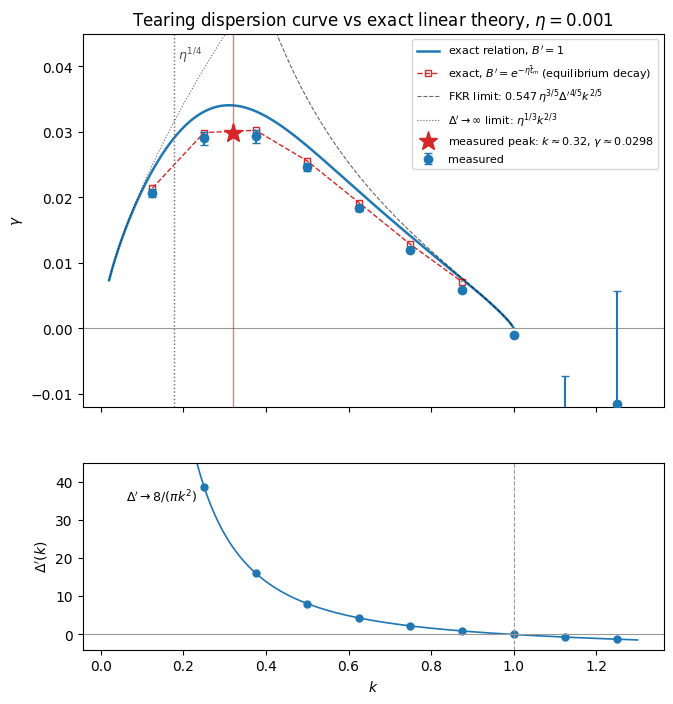

In [8]:
from scipy.special import gamma as sp_gamma
from scipy.optimize import brentq

def disp_rhs(lam):
    #RHS of the exact inner-layer matching condition; positive and monotonically
    #increasing from 0 to infinity on 0 < lam < 1 (Gamma((lam^1.5 - 1)/4) < 0 there)
    p = lam**1.5
    return -(np.pi / 8.0) * p * sp_gamma((p - 1.0) / 4.0) / sp_gamma((p + 5.0) / 4.0)

def gamma_exact(k, Bp=1.0, Dprime=None):
    #exact linear tearing growth rate: solve Delta' * delta = disp_rhs(Lambda) for
    #Lambda in (0,1), with delta = Lambda^(1/4) eta^(1/3) (kB')^(-1/3); then
    #gamma = Lambda * eta^(1/3) (kB')^(2/3). LHS-RHS is monotonic in Lambda -> brentq.
    if Dprime is None:
        Dprime = dprime_analytic(k)
    if Dprime <= 0.0:
        return np.nan
    kb = k * Bp
    F = lambda lam: disp_rhs(lam) - Dprime * lam**0.25 * eta**(1.0/3.0) / kb**(1.0/3.0)
    return brentq(F, 1e-12, 1.0 - 1e-12, xtol=1e-15) * eta**(1.0/3.0) * kb**(2.0/3.0)

#---- limit check 1: small Delta' must reproduce the FKR branch, exact prefactor ----
c_fkr = ((np.pi / 8.0) * abs(sp_gamma(-0.25)) / sp_gamma(1.25)) ** (-0.8)
print(f"FKR prefactor [8G(5/4)/(pi|G(-1/4)|)]^(4/5) = {c_fkr:.4f}  (std rounded: 0.55)")
for Dp_test in [1e-3, 1e-2]:
    r = gamma_exact(0.9, Dprime=Dp_test) / (c_fkr * eta**0.6 * Dp_test**0.8 * 0.9**0.4)
    print(f"  Delta' = {Dp_test:g}: gamma_exact/gamma_FKR = {r:.6f}")
    assert abs(r - 1.0) < 1e-3, "small-Delta' limit failed"
#---- limit check 2: Delta' -> inf must saturate at gamma_max = eta^(1/3)(kB')^(2/3) ----
for Dp_test in [1e2, 1e6]:
    r = gamma_exact(0.3, Dprime=Dp_test) / (eta**(1.0/3.0) * 0.3**(2.0/3.0))
    print(f"  Delta' = {Dp_test:g}: gamma_exact/gamma_max = {r:.6f}")
assert r > 0.9999, "large-Delta' limit failed"
print("both asymptotic limits verified numerically\n")

#the exact curve over the unstable band (B' = 1)
kk = np.linspace(0.02, 0.999, 400)
gamma_ex = np.array([gamma_exact(k) for k in kk])

#decay-corrected prediction at the measured modes: B' = exp(-eta*tbar_m), tbar_m the
#fit-window midpoint (Delta' is amplitude-independent, hence unchanged -- see above)
tbars = 0.5 * (t_los + t_nl)
Bps = np.exp(-eta * tbars)
g_ex_pts = np.array([gamma_exact(k) for k in ks])
g_corr_pts = np.array([gamma_exact(k, Bp=b) for k, b in zip(ks, Bps)])

print(" m    k     B'(tbar)  gamma_meas  gamma_exact  gamma_corr  meas/exact  meas/corr")
for m in range(1, 8):
    print(f"{m:2d}  {ks[m-1]:5.3f}   {Bps[m-1]:.3f}    {gammas[m-1]:+.5f}    "
          f"{g_ex_pts[m-1]:+.5f}    {g_corr_pts[m-1]:+.5f}    "
          f"{gammas[m-1]/g_ex_pts[m-1]:5.3f}       {gammas[m-1]/g_corr_pts[m-1]:5.3f}")

#thin asymptote references (pedagogy only -- the exact curve is the prediction)
kk2 = np.linspace(0.02, 1.3, 400)
Dp2 = np.array([dprime_analytic(k) for k in kk2])
mpos = (kk2 < 1.0) & (Dp2 > 0)
gamma_fkr = c_fkr * eta**0.6 * np.where(mpos, Dp2, np.nan)**0.8 * kk2**0.4
gamma_cop = eta**(1.0/3.0) * kk2**(2.0/3.0)

#peak of the measured curve: parabola through the three points around the maximum
i = int(np.argmax(gammas))
denom = gammas[i-1] - 2.0*gammas[i] + gammas[i+1]
k_peak = ks[i] + 0.5 * dk * (gammas[i-1] - gammas[i+1]) / denom
g_peak = gammas[i] - (gammas[i-1] - gammas[i+1])**2 / (8.0 * denom)
ipk = int(np.nanargmax(gamma_ex))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.5, 8), sharex=True,
                               height_ratios=[2, 1])
ax1.errorbar(ks, gammas, yerr=g_sys, fmt="o", ms=6, capsize=3, zorder=5,
             label="measured")
ax1.plot(kk, gamma_ex, "C0-", lw=1.8, label=r"exact relation, $B'=1$")
ax1.plot(ks[:7], g_corr_pts[:7], "C3s--", ms=5, lw=1.0, mfc="none",
         label=r"exact, $B'=e^{-\eta\bar t_m}$ (equilibrium decay)")
ax1.plot(kk2, gamma_fkr, "k--", lw=0.8, alpha=0.6,
         label=rf"FKR limit: ${c_fkr:.3f}\,\eta^{{3/5}}\Delta'^{{4/5}}k^{{2/5}}$")
ax1.plot(kk2, gamma_cop, "k:", lw=0.8, alpha=0.6,
         label=r"$\Delta'\to\infty$ limit: $\eta^{1/3}k^{2/3}$")
ax1.axhline(0.0, color="0.6", lw=0.8)
ax1.axvline(k_peak, color="C3", ls="-", lw=1, alpha=0.6)
ax1.plot([k_peak], [g_peak], "C3*", ms=14,
         label=rf"measured peak: $k\approx{k_peak:.2f}$, $\gamma\approx{g_peak:.4f}$")
ax1.axvline(eta**0.25, color="0.4", ls=":", lw=1)
ax1.text(eta**0.25 + 0.01, 0.041, r"$\eta^{1/4}$", fontsize=9, color="0.3")
ax1.set_ylim(-0.012, 0.045)
ax1.set_ylabel(r"$\gamma$")
ax1.legend(fontsize=8, loc="upper right")
ax1.set_title(rf"Tearing dispersion curve vs exact linear theory, $\eta={eta:g}$")
ax2.plot(kk2, Dp2, "C0-", lw=1.2)
ax2.plot(ks, [dprime_analytic(k) for k in ks], "C0o", ms=5)
ax2.axhline(0.0, color="0.6", lw=0.8)
ax2.axvline(1.0, color="0.6", ls="--", lw=0.8)
ax2.set_ylim(-4, 45)
ax2.set_xlabel(r"$k$")
ax2.set_ylabel(r"$\Delta'(k)$")
ax2.text(0.06, 35, r"$\Delta'\to 8/(\pi k^2)$", fontsize=9)

delta = (gammas[i] * eta)**0.25 / np.sqrt(ks[i])   #layer width at the measured peak
print(f"\nexact-curve peak: k = {kk[ipk]:.3f}, gamma = {gamma_ex[ipk]:.4f};  "
      f"measured peak: k ~ {k_peak:.2f}, gamma ~ {g_peak:.4f}")
print(f"slab estimate k_peak ~ eta^(1/4) = {eta**0.25:.2f}")
print(f"layer width at the measured peak: delta = {delta:.3f};  "
      f"Delta'(k_peak)*delta = {dprime_analytic(k_peak)*delta:.1f}")
print(f"B'-decay lowers the prediction by "
      f"{100.0*(1.0 - np.nanmean(g_corr_pts[:7]/g_ex_pts[:7])):.0f}% on average "
      f"(modes 1-7)")

### Cross-check against `tearing-mode-2D` at $k=1/2$

`tearing-mode-2D` measures $\gamma(k{=}\tfrac12,\eta{=}10^{-3}) = 0.0249$ in its own
$L_y=4\pi$ box (there the seeded $k=1/2$ mode is the fundamental, $k_y$ index 1). Same
equilibrium, same $\eta$, and now the same inviscid physics -- but a different box,
resolution, precision (fp32 vs fp64), seed amplitude and fit window. The two
measurements should therefore *agree* to a few percent: an end-to-end consistency
check between the two notebooks, not a new physics number. (Historical note: a $Pm=1$
version of `tearing-mode-2D` measured $0.0188$ here -- $Pm=1$ viscosity suppresses
this mode by $\sim24\%$; that is now an exercise in both notebooks.)

In [9]:
#cross-check with tearing-mode-2D: same equilibrium, same eta = 1e-3, same k = 1/2,
#and both runs now inviscid (nu = 0) -- the only differences are box size (Ly = 4*pi
#vs 16*pi), resolution, precision (fp32 vs fp64), seed amplitude and fit window.
#Two independent measurements of the same linear growth rate: they should agree to a
#few percent, and they do.
ref_tm2d = 0.0249         #tearing-mode-2D featured run: Ly = 4*pi, fp32, nu = 0
g_half = gammas[3]        #m = 4 is k = 0.5 here
ratio = g_half / ref_tm2d
print(f"gamma(k=0.5) this notebook (Ly=16*pi, fp64):   {g_half:.4f}")
print(f"gamma(k=0.5) tearing-mode-2D (Ly=4*pi, fp32):  {ref_tm2d:.4f}")
print(f"ratio = {ratio:.3f}  (|ratio - 1| = {abs(ratio-1.0)*100:.1f}%)")
assert abs(ratio - 1.0) < 0.05, "the two inviscid tearing notebooks disagree at k=0.5"


gamma(k=0.5) this notebook (Ly=16*pi, fp64):   0.0246
gamma(k=0.5) tearing-mode-2D (Ly=4*pi, fp32):  0.0249
ratio = 0.990  (|ratio - 1| = 1.0%)


### Discussion

**The curve has the advertised shape.** $\gamma(k)$ rises from small $k$, peaks at
$k\approx0.3$, falls through the near-marginal $m=7$, and crosses zero at the band
edge: $m=8$ ($k=1$, $\Delta'=0$) *decays* at $\gamma = -0.99\times10^{-3} \approx
-\eta k^2$ -- with $\Delta'=0$ and no viscosity there is nothing this mode can do but
resistively diffuse, and the measured null hits that value to $1\%$. $m=9,10$ are
genuinely tearing-stable, but their fitted rows are the messiest in the table (rms
residuals $0.27$ and $0.87$): as flagged above, the nonlinear beats overtake their
decay *inside* the fit window, so those two numbers are qualitative only.

**Measurement vs exact theory -- now inviscid vs inviscid.** The exact relation and
the data agree on where the peak is ($k\approx0.31$ for the $B'=1$ theory curve,
$k\approx0.32$ measured, both well above the prefactor-free slab estimate
$\eta^{1/4}=0.18$) and, now, essentially on its height. The measured points sit
$12$-$15\%$ below the $B'=1$ curve, and the equilibrium's resistive decay accounts
for almost all of it: by the fit-window midpoints the field has decayed to
$B'=e^{-\eta\bar t}\approx0.83$-$0.86$, lowering the prediction by $\sim9$-$11\%$,
and the decay-corrected ratios come out meas/corr $= 0.95$-$0.97$ for $m=1$-$5$. (The
$Pm=1$ version of this run measured $0.80$-$0.84$ here -- the difference was viscosity,
which the inviscid relation legitimately omits.) The residual few percent is the
remaining error budget: the layers are not asymptotically thin ($\Delta'\delta$ runs
from $\sim30$ at $m=1$ to $\sim0.05$ at $m=7$ -- printed above), and the fit windows
are finite on a slowly drifting background. Toward marginality the shortfall grows
(meas/corr $\approx0.93$ at $m=6$, $0.82$ at $m=7$), as it should: those $\gamma$'s
are small in absolute terms, so the residual drift of a near-marginal mode is
proportionally much larger.

**The $k=1/2$ cross-check.** The comparison above closes the loop between the two
tearing notebooks: $\gamma = 0.0246$ here vs $0.0249$ in `tearing-mode-2D` -- two
independent inviscid runs of the same mode, in different boxes, resolutions and
precisions, agreeing to $\sim1\%$. (The historical $Pm=1$ number, $0.0188$, is what
the same mode does with $\nu=\eta$: a $\sim24\%$ viscous suppression -- now an
exercise in both notebooks rather than a systematic error in either.)

**Quality control.** The seeding design still does its job: every unstable mode is a
straight line on the semilog plot over 4-6 decades, the $m=8$ null lands on $-\eta
k^2$, and the messiest fits are exactly the ones that should be (the beat-contaminated
stable band edge, handled by the global cutoff and flagged by their rms). The
late-time inviscid caveat -- marginally resolved vorticity layers after
$t\approx450$ -- is documented above and touches nothing quantitative.

**Refining the curve.** Two natural upgrades, in increasing cost: (i) $L_y=32\pi$ at
$128\times2048$ halves the mode spacing to $\Delta k=1/16$ ($\sim2\times$ the cost,
still laptop-feasible) and pins the peak much more tightly; (ii) $256\times4096$ at two
resistivities (e.g. $10^{-3}$ and $2.5\times10^{-4}$) on a GPU turns this into a
research-grade measurement of $k_{peak}(\eta)$, testing the $\eta^{1/4}$ scaling
directly.

### Things to try

- **Q1 -- phases:** rerun with a different phase seed. The linear rates should be
  identical to fit precision; the *saturated* state generally is not -- why?
- **Q2 -- eigenfunction structure:** at some $t$ inside the fit window, plot
  $|\hat\psi(k_x, k_y{=}m\Delta k)|$ vs $x$ (inverse-fft only in $x$) for a small-$k$
  and a large-$k$ mode and compare with the outer solution
  $\cos(\kappa(x-\pi/2))$ -- you can *see* the constant-$\psi$ layer at large $k$ and
  its breakdown at small $k$.
- **Q3 -- single-mode check:** rerun with only $m=2$ seeded at the same $\epsilon$.
  Does $\gamma$ change? (It should not, before $t_{nl}$ -- that is the superposition
  assumption, now tested rather than asserted.)
- **Q4 -- island competition:** from the final snapshots, measure the island widths of
  the surviving chains at each resonant surface. Which $k$ wins the nonlinear stage --
  the linearly fastest, or a longer-wavelength survivor of island coalescence?
- **Q5 -- the $Pm$ scan:** the historical $Pm=1$ point ($\gamma=0.0188$ at $k=0.5$)
  samples the viscous correction at exactly one viscosity. Map it out: rerun at $\nu = 10^{-4}$, $3\times10^{-4}$,
  $10^{-3}$ (fixed $\eta=10^{-3}$) and watch $\gamma(k{=}0.5)$ fall from $0.0246$
  toward $0.0188$ -- then compare with visco-resistive layer theory, where strong
  viscosity suppresses the FKR-branch rate like $Pm^{-1/3}$.